In [ ]:
''' 
Heart Disease Prediction System: This system uses patient clinical data like age, BP, cholesterol, etc. Data is cleaned, missing values removed
, and scaling is applied so all features are in same range. Feature selection means selecting most important attributes (like cholesterol, BP) so
model becomes fast and accurate. Logistic Regression and KNN are trained to classify risk or no risk. Performance is checked using accuracy,
precision, recall, and F1-score.
'''

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
data=pd.read_csv(r"C:\Users\siddh\OneDrive\Desktop\PBL1\Heart_Disease_3000_Medical.csv")
data

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,58.0,0.0,4.0,146.0,201.0,0.0,2.0,168.0,1.0,3.48,2.0,2.0,6.0,1.0
2,44.0,1.0,4.0,127.0,212.0,0.0,1.0,193.0,0.0,1.19,1.0,1.0,7.0,0.0
3,72.0,0.0,1.0,158.0,173.0,0.0,1.0,154.0,1.0,2.80,1.0,3.0,3.0,1.0
4,37.0,1.0,4.0,121.0,243.0,1.0,0.0,185.0,1.0,3.17,3.0,3.0,3.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,75.0,0.0,3.0,142.0,197.0,0.0,1.0,132.0,1.0,1.52,2.0,0.0,6.0,1.0
2996,33.0,0.0,3.0,115.0,186.0,0.0,0.0,191.0,0.0,1.93,2.0,2.0,3.0,0.0
2997,74.0,1.0,1.0,155.0,223.0,1.0,2.0,131.0,1.0,2.68,2.0,3.0,7.0,1.0
2998,49.0,0.0,3.0,128.0,256.0,1.0,1.0,177.0,1.0,3.48,2.0,1.0,6.0,1.0


In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      2853 non-null   float64
 1   Sex                      2853 non-null   float64
 2   Chest pain type          2853 non-null   float64
 3   BP                       2853 non-null   float64
 4   Cholesterol              2853 non-null   float64
 5   FBS over 120             2853 non-null   float64
 6   EKG results              2853 non-null   float64
 7   Max HR                   2853 non-null   float64
 8   Exercise angina          2853 non-null   float64
 9   ST depression            2853 non-null   float64
 10  Slope of ST              2853 non-null   float64
 11  Number of vessels fluro  2853 non-null   float64
 12  Thallium                 2853 non-null   float64
 13  Heart Disease            2853 non-null   float64
dtypes: float64(14)
memory usage: 328.3 

In [7]:
data.shape

(3000, 14)

In [8]:
data.size

42000

In [9]:
data.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,58.0,0.0,4.0,146.0,201.0,0.0,2.0,168.0,1.0,3.48,2.0,2.0,6.0,1.0
2,44.0,1.0,4.0,127.0,212.0,0.0,1.0,193.0,0.0,1.19,1.0,1.0,7.0,0.0
3,72.0,0.0,1.0,158.0,173.0,0.0,1.0,154.0,1.0,2.80,1.0,3.0,3.0,1.0
4,37.0,1.0,4.0,121.0,243.0,1.0,0.0,185.0,1.0,3.17,3.0,3.0,3.0,1.0


In [10]:
data.tail()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
2995,75.0,0.0,3.0,142.0,197.0,0.0,1.0,132.0,1.0,1.52,2.0,0.0,6.0,1.0
2996,33.0,0.0,3.0,115.0,186.0,0.0,0.0,191.0,0.0,1.93,2.0,2.0,3.0,0.0
2997,74.0,1.0,1.0,155.0,223.0,1.0,2.0,131.0,1.0,2.68,2.0,3.0,7.0,1.0
2998,49.0,0.0,3.0,128.0,256.0,1.0,1.0,177.0,1.0,3.48,2.0,1.0,6.0,1.0
2999,46.0,1.0,4.0,124.0,207.0,0.0,2.0,180.0,0.0,0.51,3.0,3.0,6.0,0.0


In [11]:
data.describe()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
count,2853.000000,2853.000000,2853.000000,2853.000000,2853.000000,2853.000000,2853.000000,2853.000000,2853.000000,2853.000000,2853.000000,2853.000000,2853.000000,2853.000000
mean,55.823247,0.532549,2.604581,134.219803,227.600984,0.573635,1.071238,166.130689,0.541132,1.902962,2.027625,1.582253,5.527866,0.541132
std,16.431088,0.571864,1.290939,17.381127,42.180369,0.570778,0.939608,19.609827,0.571907,1.158091,0.951011,1.260304,1.938459,0.571907
min,30.000000,0.000000,1.000000,88.000000,95.000000,0.000000,0.000000,116.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,42.000000,0.000000,2.000000,122.000000,200.000000,0.000000,0.000000,152.000000,0.000000,1.020000,1.000000,1.000000,3.000000,0.000000
50%,55.000000,1.000000,3.000000,134.000000,225.000000,1.000000,1.000000,165.000000,1.000000,1.810000,2.000000,2.000000,6.000000,1.000000
75%,68.000000,1.000000,4.000000,145.000000,252.000000,1.000000,2.000000,178.000000,1.000000,2.690000,3.000000,3.000000,7.000000,1.000000
max,111.978706,2.489381,7.031151,193.668288,371.643461,2.526346,4.287362,233.347601,2.497512,5.864030,5.280217,5.902788,12.166711,2.497512


In [12]:
data.isnull().sum()

Age                        147
Sex                        147
Chest pain type            147
BP                         147
Cholesterol                147
FBS over 120               147
EKG results                147
Max HR                     147
Exercise angina            147
ST depression              147
Slope of ST                147
Number of vessels fluro    147
Thallium                   147
Heart Disease              147
dtype: int64

In [13]:
# DATA CLEANING

In [14]:
data.dropna(how='all', inplace=True)
data

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
1,58.0,0.0,4.0,146.0,201.0,0.0,2.0,168.0,1.0,3.48,2.0,2.0,6.0,1.0
2,44.0,1.0,4.0,127.0,212.0,0.0,1.0,193.0,0.0,1.19,1.0,1.0,7.0,0.0
3,72.0,0.0,1.0,158.0,173.0,0.0,1.0,154.0,1.0,2.80,1.0,3.0,3.0,1.0
4,37.0,1.0,4.0,121.0,243.0,1.0,0.0,185.0,1.0,3.17,3.0,3.0,3.0,1.0
5,50.0,0.0,1.0,130.0,218.0,0.0,2.0,174.0,0.0,1.46,2.0,2.0,6.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,75.0,0.0,3.0,142.0,197.0,0.0,1.0,132.0,1.0,1.52,2.0,0.0,6.0,1.0
2996,33.0,0.0,3.0,115.0,186.0,0.0,0.0,191.0,0.0,1.93,2.0,2.0,3.0,0.0
2997,74.0,1.0,1.0,155.0,223.0,1.0,2.0,131.0,1.0,2.68,2.0,3.0,7.0,1.0
2998,49.0,0.0,3.0,128.0,256.0,1.0,1.0,177.0,1.0,3.48,2.0,1.0,6.0,1.0


In [15]:
data.drop_duplicates(inplace=True)
data

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
1,58.0,0.0,4.0,146.0,201.0,0.0,2.0,168.0,1.0,3.48,2.0,2.0,6.0,1.0
2,44.0,1.0,4.0,127.0,212.0,0.0,1.0,193.0,0.0,1.19,1.0,1.0,7.0,0.0
3,72.0,0.0,1.0,158.0,173.0,0.0,1.0,154.0,1.0,2.80,1.0,3.0,3.0,1.0
4,37.0,1.0,4.0,121.0,243.0,1.0,0.0,185.0,1.0,3.17,3.0,3.0,3.0,1.0
5,50.0,0.0,1.0,130.0,218.0,0.0,2.0,174.0,0.0,1.46,2.0,2.0,6.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,75.0,0.0,3.0,142.0,197.0,0.0,1.0,132.0,1.0,1.52,2.0,0.0,6.0,1.0
2996,33.0,0.0,3.0,115.0,186.0,0.0,0.0,191.0,0.0,1.93,2.0,2.0,3.0,0.0
2997,74.0,1.0,1.0,155.0,223.0,1.0,2.0,131.0,1.0,2.68,2.0,3.0,7.0,1.0
2998,49.0,0.0,3.0,128.0,256.0,1.0,1.0,177.0,1.0,3.48,2.0,1.0,6.0,1.0


In [16]:
# Age (median)
data['Age'] = data['Age'].fillna(data['Age'].median())
# Sex (mode)
data['Sex'] = data['Sex'].fillna(data['Sex'].mode()[0])
# Chest pain type (mode)
data['Chest pain type'] = data['Chest pain type'].fillna(data['Chest pain type'].mode()[0])
# BP (median)
data['BP'] = data['BP'].fillna(data['BP'].median())
# Cholesterol (median)
data['Cholesterol'] = data['Cholesterol'].fillna(data['Cholesterol'].median())
# FBS (mode)
data['FBS over 120'] = data['FBS over 120'].fillna(data['FBS over 120'].mode()[0])
# EKG (mode)
data['EKG results'] = data['EKG results'].fillna(data['EKG results'].mode()[0])
# Max HR (mean)
data['Max HR'] = data['Max HR'].fillna(data['Max HR'].mean())
# Exercise angina (mode)
data['Exercise angina'] = data['Exercise angina'].fillna(data['Exercise angina'].mode()[0])
# ST depression (median)
data['ST depression'] = data['ST depression'].fillna(data['ST depression'].median())
# Slope (mode)
data['Slope of ST'] = data['Slope of ST'].fillna(data['Slope of ST'].mode()[0])
# Vessels (mode)
data['Number of vessels fluro'] = data['Number of vessels fluro'].fillna(data['Number of vessels fluro'].mode()[0])
# Thallium (mode)
data['Thallium'] = data['Thallium'].fillna(data['Thallium'].mode()[0])
# Target column (important)
data['Heart Disease'] = data['Heart Disease'].fillna(data['Heart Disease'].mode()[0])

In [17]:
data.isnull().sum()

Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

In [18]:
# Removing Outliers

In [19]:
# Select numeric columns
numeric_cols = data.select_dtypes(include=['number']).columns
outlier_count = {}
for col in numeric_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = data[(data[col] < lower) | (data[col] > upper)].shape[0]
    outlier_count[col] = count

print("Outliers in each column:\n")
for k,v in outlier_count.items():
    print(f"{k}: {v}")

Outliers in each column:

Age: 1
Sex: 0
Chest pain type: 0
BP: 3
Cholesterol: 12
FBS over 120: 1
EKG results: 0
Max HR: 3
Exercise angina: 0
ST depression: 1
Slope of ST: 0
Number of vessels fluro: 1
Thallium: 0
Heart Disease: 0


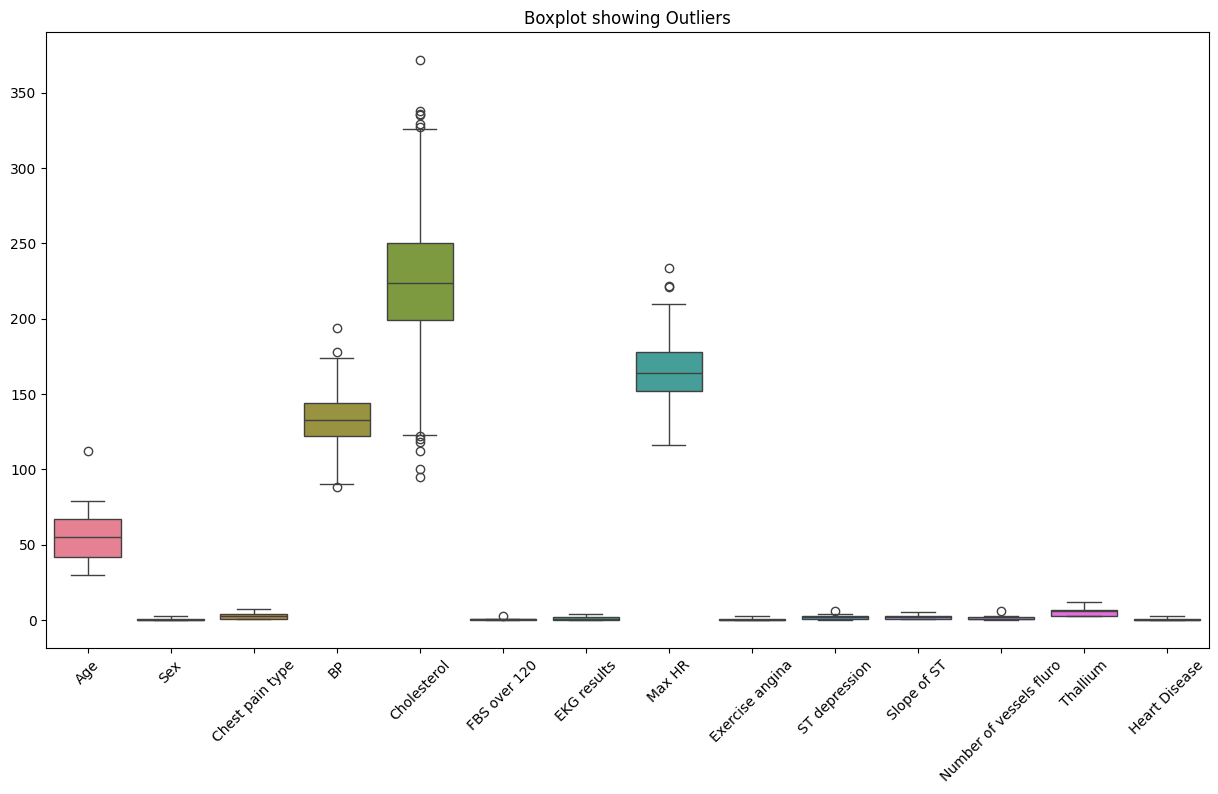

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15,8))
sns.boxplot(data=data[numeric_cols])
plt.xticks(rotation=45)
plt.title("Boxplot showing Outliers")
plt.show()

In [ ]:
# Inference : Detecting Outliers using boxplot

In [22]:
# Remove Outliers
data_clean = data.copy()

for col in numeric_cols:
    Q1 = data_clean[col].quantile(0.25)
    Q3 = data_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    data_clean = data_clean[
        (data_clean[col] >= lower) & (data_clean[col] <= upper)
    ]

print("Shape before:", data.shape)
print("Shape after removing outliers:", data_clean.shape)

Shape before: (2794, 14)
Shape after removing outliers: (2778, 14)


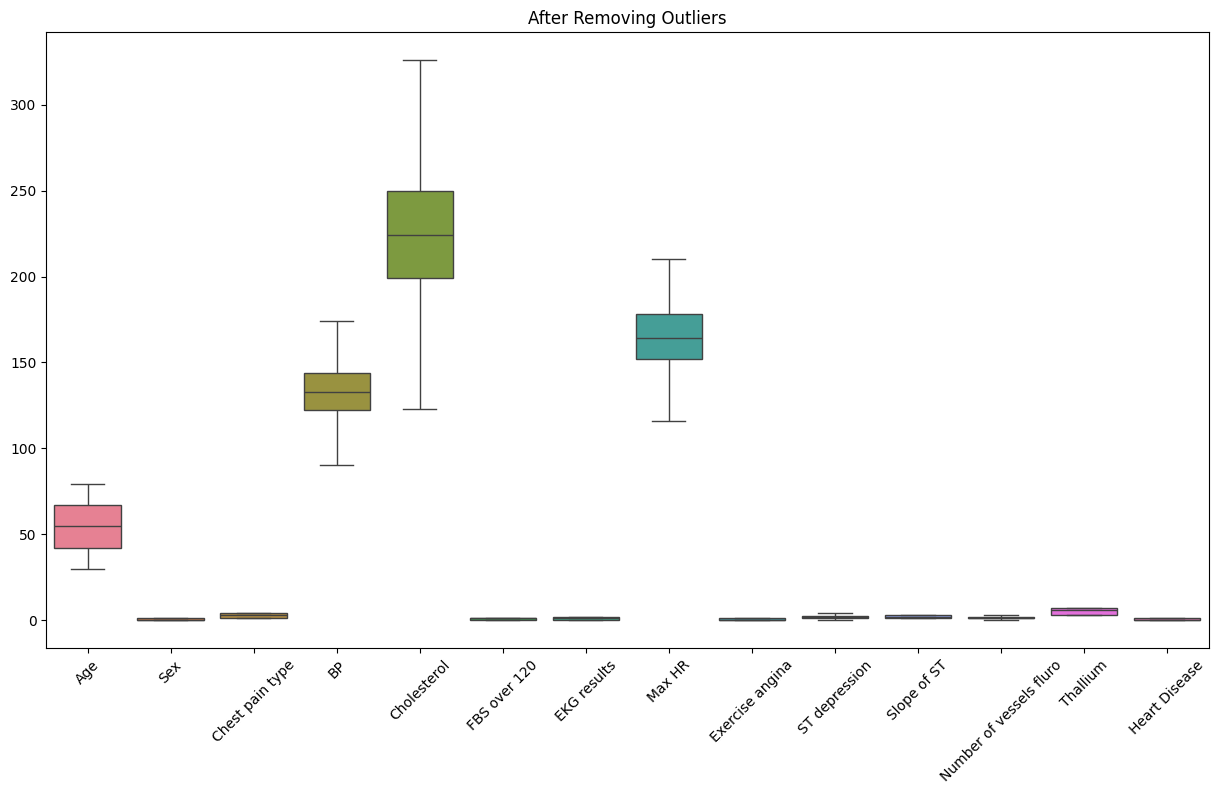

In [23]:
plt.figure(figsize=(15,8))
sns.boxplot(data=data_clean[numeric_cols])
plt.xticks(rotation=45)
plt.title("After Removing Outliers")
plt.show()

In [ ]:
#Inference : data distribtuion shown after removing outliers

In [24]:
# plotting graphs 

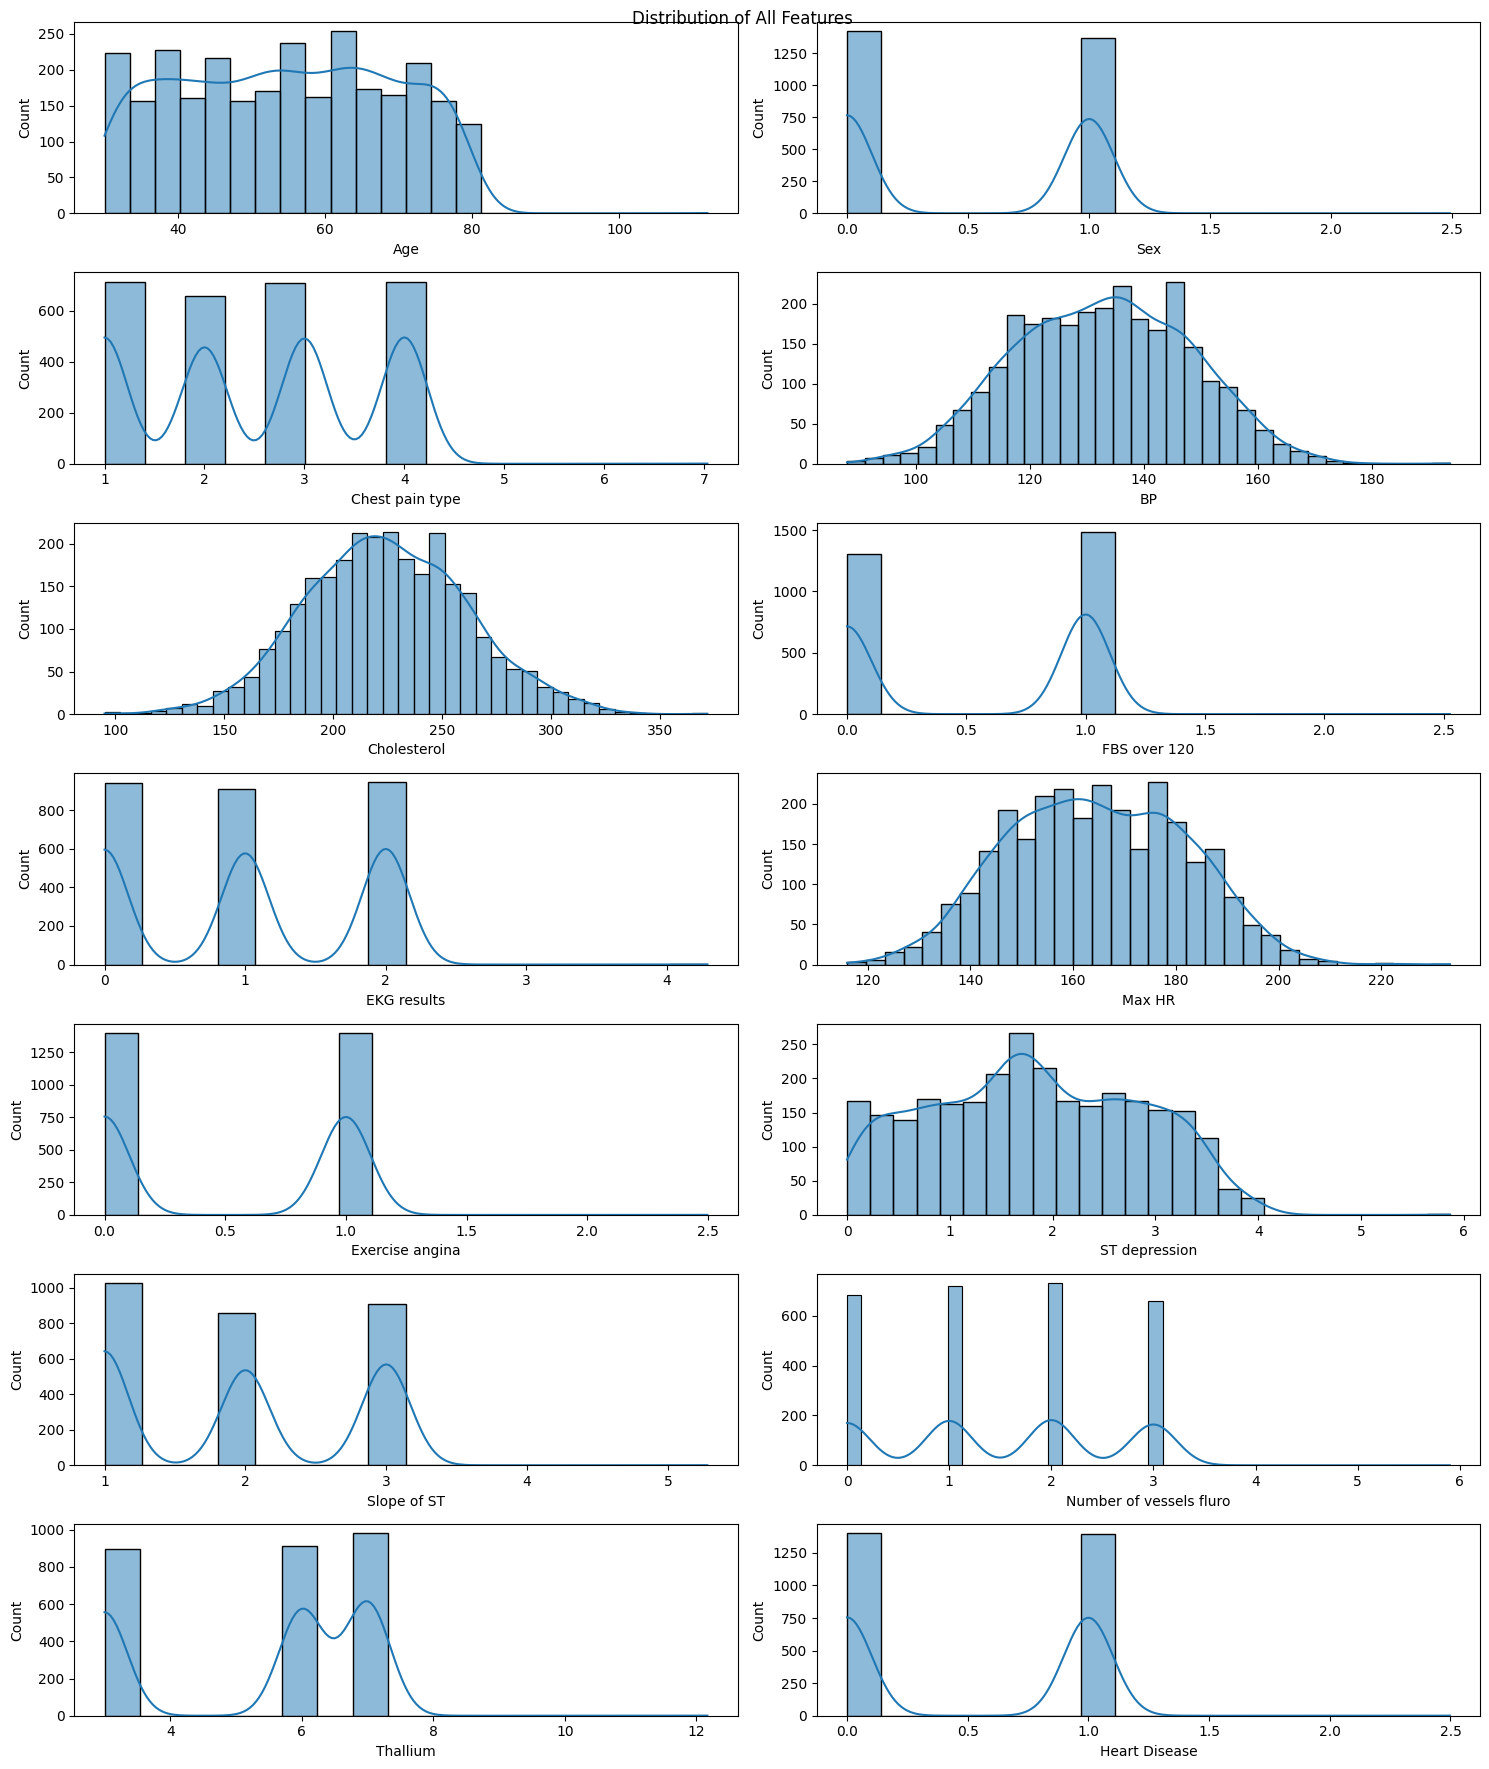

In [25]:
fig , axes = plt.subplots(7,2, figsize=(15,18))
axes= axes.flatten()
for i,col in enumerate(data.columns):
    sns.histplot(data[col] , kde=True , ax=axes[i])
    
plt.suptitle("Distribution of All Features ")
plt.tight_layout()
plt.show()

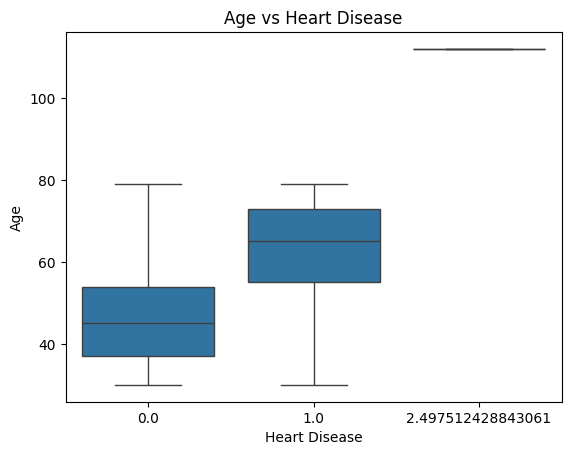

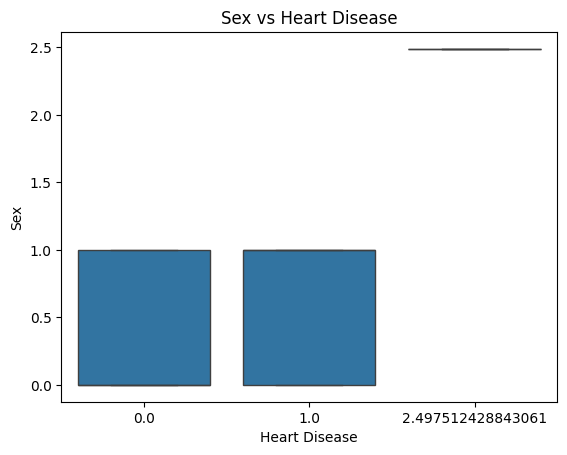

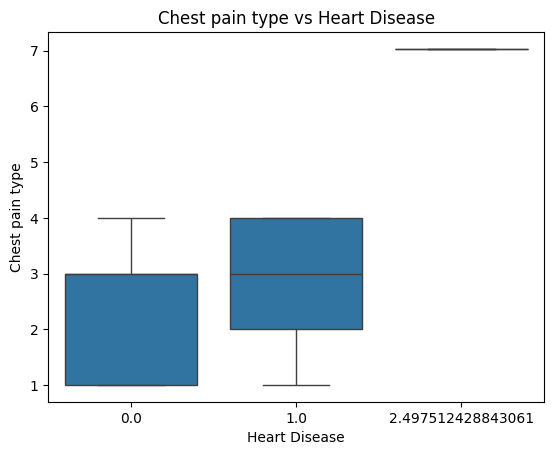

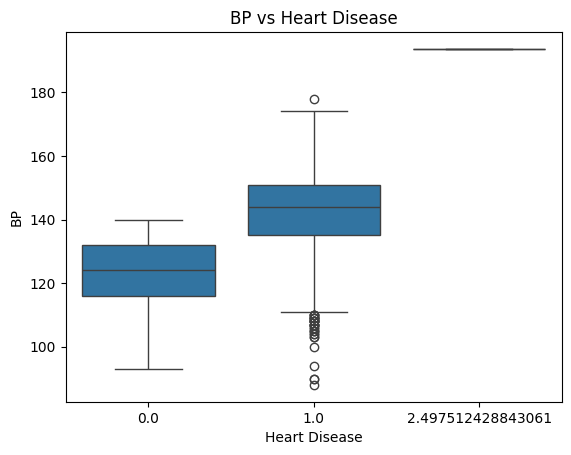

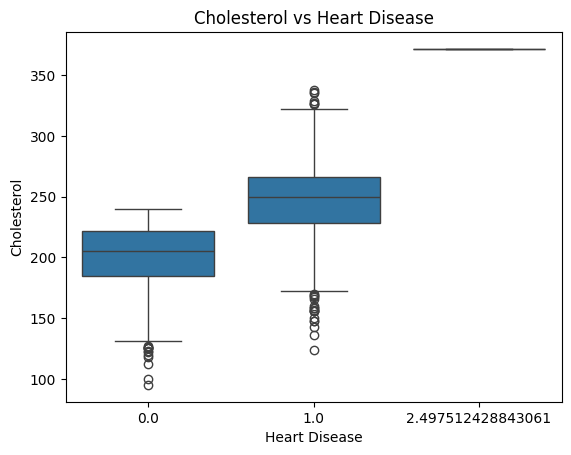

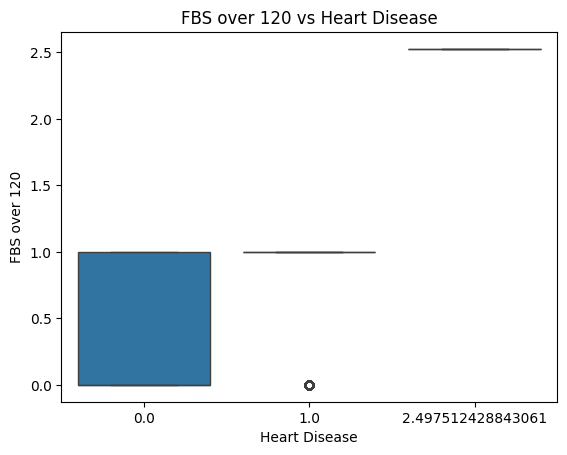

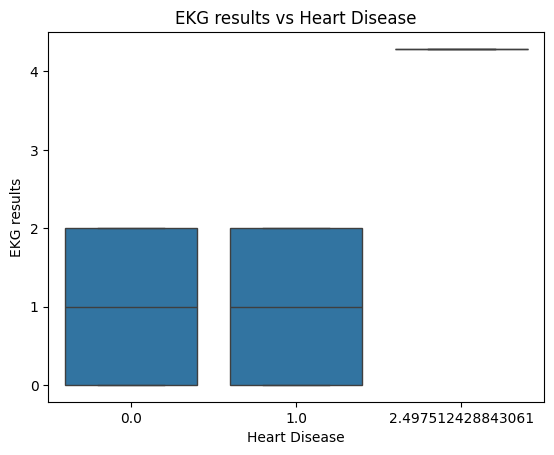

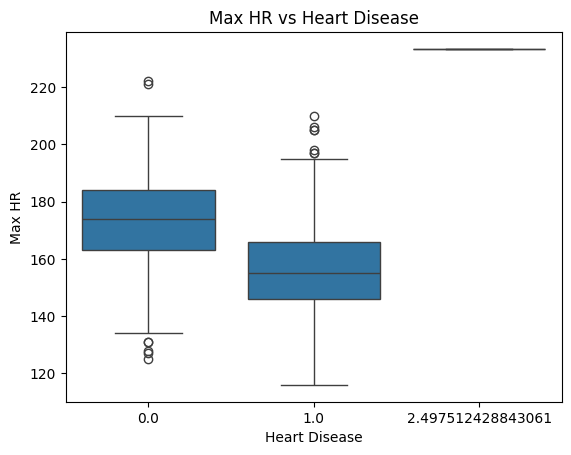

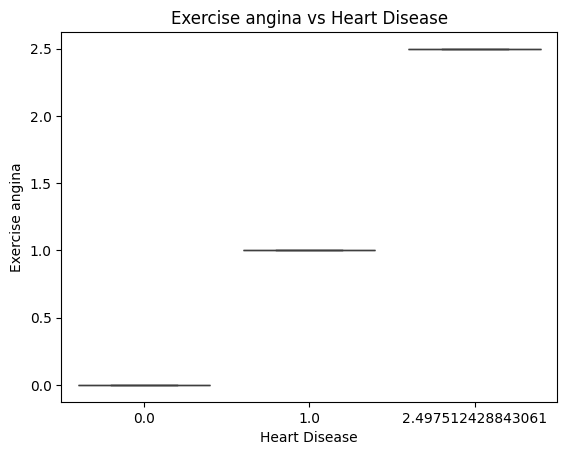

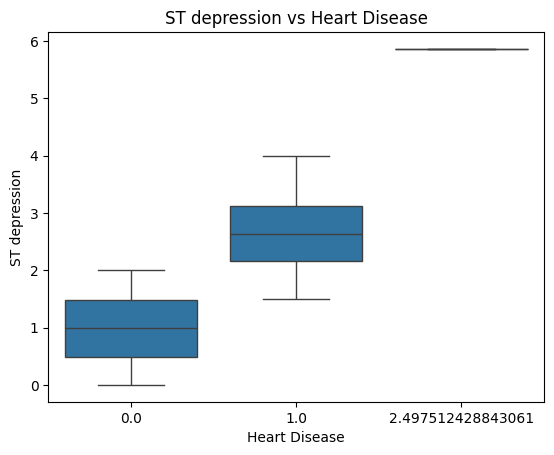

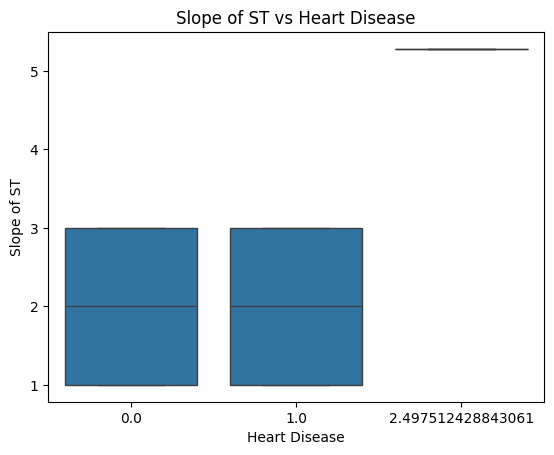

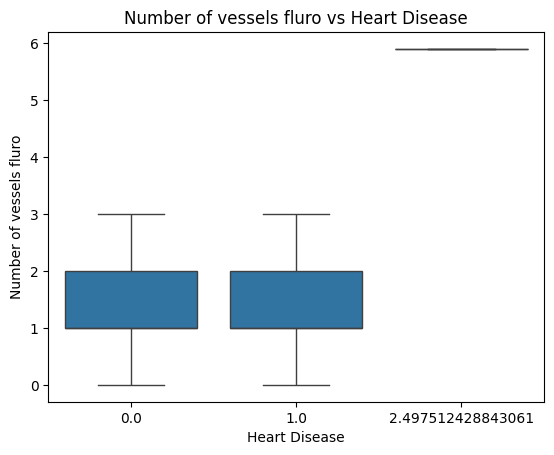

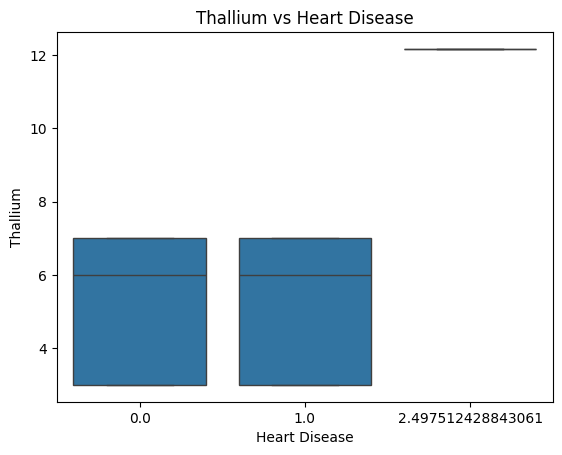

In [28]:
# Feature vs Target Graphs
target = 'Heart Disease'
for col in data.columns:
    if col != target:
        plt.figure()
        sns.boxplot(x=data[target], y=data[col])
        plt.title(f"{col} vs Heart Disease")
        plt.show()

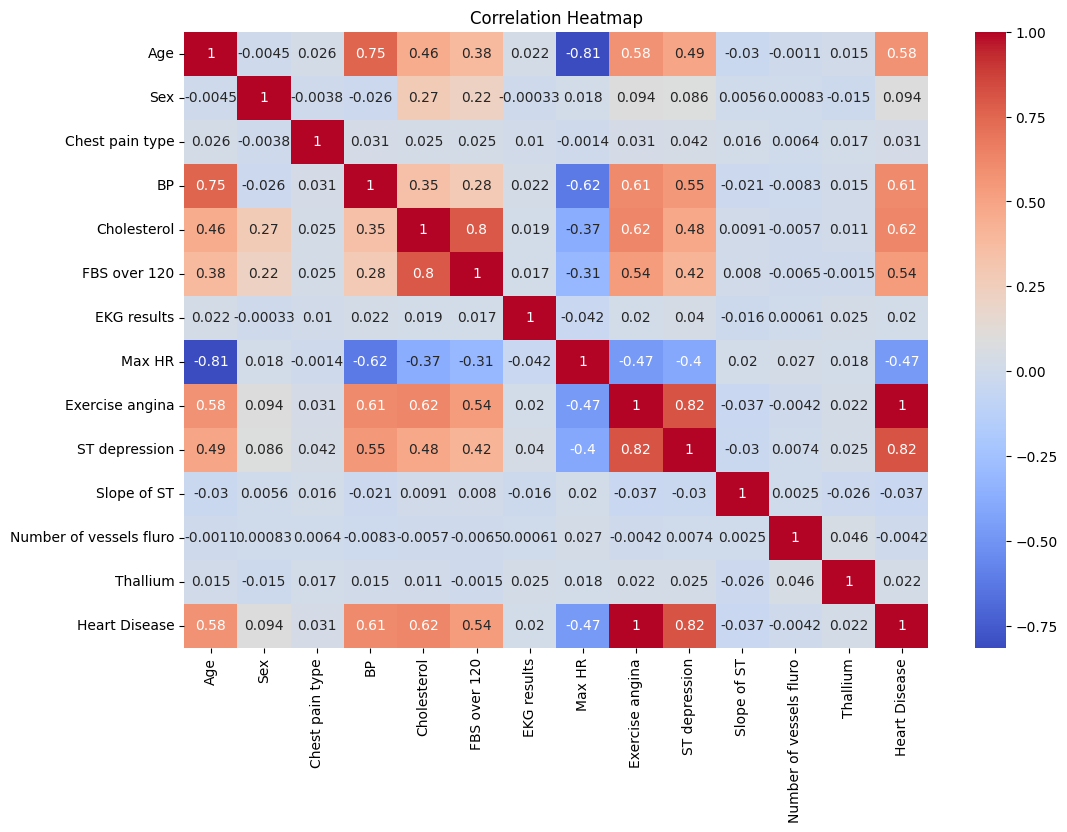

In [29]:
plt.figure(figsize=(12,8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [30]:
X = data.drop('Heart Disease', axis=1)
y = data['Heart Disease']

In [31]:
# Label Encoding

In [32]:
from sklearn.preprocessing import LabelEncoder

for col in X.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

In [33]:
#Min Max and Standardisation

In [34]:
from sklearn.preprocessing import StandardScaler

scaler_std = StandardScaler()

X_standardized = scaler_std.fit_transform(X)

print("Standardized Data (first 5 rows):\n", X_standardized[:5])

Standardized Data (first 5 rows):
 [[ 0.23338307 -0.98000777  1.31672356  0.85551243 -0.63679991 -1.06409771
   1.2102867   0.19144171  0.99769229  1.63576461  0.04924872  0.46103239
   0.36048572]
 [-0.73830308  1.01501073  1.31672356 -0.39144178 -0.33947345 -1.06409771
  -0.00403646  1.64673713 -0.99697483 -0.61987529 -1.15020377 -0.44475976
   0.949203  ]
 [ 1.20506921 -0.98000777 -1.33636767  1.64306246 -1.39363091 -1.06409771
  -0.00403646 -0.62352372  0.99769229  0.96596761 -1.15020377  1.36682454
  -1.4056661 ]
 [-1.22414615  1.01501073  1.31672356 -0.78521679  0.49844659  0.93458219
  -1.21835961  1.1810426   0.99769229  1.33041598  1.24870122  1.36682454
  -1.4056661 ]
 [-0.32186616 -0.98000777 -1.33636767 -0.19455427 -0.17729538 -1.06409771
   1.2102867   0.54071261 -0.99697483 -0.35392648  0.04924872  0.46103239
   0.36048572]]


In [35]:
from sklearn.preprocessing import MinMaxScaler

scaler_mm = MinMaxScaler()

X_minmax = scaler_mm.fit_transform(X)

print("Min-Max Scaled Data (first 5 rows):\n", X_minmax[:5])

Min-Max Scaled Data (first 5 rows):
 [[0.34155211 0.         0.49741748 0.54888748 0.38316467 0.
  0.46648728 0.44312793 0.40039841 0.59344852 0.233633   0.33882295
  0.32727115]
 [0.17077605 0.40170624 0.49741748 0.36907951 0.42292704 0.
  0.23324364 0.65617021 0.         0.20293211 0.         0.16941148
  0.43636153]
 [0.51232816 0.         0.         0.6624504  0.28195136 0.
  0.23324364 0.32382426 0.40039841 0.47748731 0.         0.50823443
  0.        ]
 [0.08538803 0.40170624 0.49741748 0.31229805 0.53498463 0.39582856
  0.         0.58799668 0.40039841 0.54058385 0.46726601 0.50823443
  0.        ]
 [0.24396579 0.         0.         0.39747024 0.44461561 0.
  0.46648728 0.49425808 0.         0.24897553 0.233633   0.33882295
  0.32727115]]


In [36]:
import pandas as pd

X_standardized_df = pd.DataFrame(X_standardized, columns=X.columns)
X_minmax_df = pd.DataFrame(X_minmax, columns=X.columns)

print(X_standardized_df.head())
print(X_minmax_df.head())

        Age       Sex  Chest pain type        BP  Cholesterol  FBS over 120  \
0  0.233383 -0.980008         1.316724  0.855512    -0.636800     -1.064098   
1 -0.738303  1.015011         1.316724 -0.391442    -0.339473     -1.064098   
2  1.205069 -0.980008        -1.336368  1.643062    -1.393631     -1.064098   
3 -1.224146  1.015011         1.316724 -0.785217     0.498447      0.934582   
4 -0.321866 -0.980008        -1.336368 -0.194554    -0.177295     -1.064098   

   EKG results    Max HR  Exercise angina  ST depression  Slope of ST  \
0     1.210287  0.191442         0.997692       1.635765     0.049249   
1    -0.004036  1.646737        -0.996975      -0.619875    -1.150204   
2    -0.004036 -0.623524         0.997692       0.965968    -1.150204   
3    -1.218360  1.181043         0.997692       1.330416     1.248701   
4     1.210287  0.540713        -0.996975      -0.353926     0.049249   

   Number of vessels fluro  Thallium  
0                 0.461032  0.360486  
1       